# Exploration of California Vehicle Miles Traveled Data
We will visualize California Vehicle Miles Traveled (VMT) data using the example of San Francisco. This provides a template for student analysis of the potential climate benefits of infill housing development for another city or county in California, following approaches similar to Subin (2024[a](https://ternercenter.berkeley.edu/research-and-policy/role-of-new-housing-in-reducing-climate-pollution/), [b](https://ternercenter.berkeley.edu/blog/how-much-can-new-housing-contribute-to-state-climate-action/)) and Subin et al ([2026](https://ternercenter.berkeley.edu/blog/projected-transportation-impacts-of-california-housing-plans/)).

The source data consists of preliminary VMT estimates developed by [Chatman et al 2025](https://escholarship.org/uc/item/99j4s0bp) for the California Air Resources Board, provided by CARB to Zack Subin in July 2026 for educational use. This data file is available to students via the course Canvas site and should be downloaded to the `inputdata` folder. Note: a version of these estimates is now publicly available as of Sep 2026, posted by CARB for public comment at the [California Climate Investments page](https://www.caclimateinvestments.ca.gov/public-participation-opportunities), integrated into the [Draft Affordable Housing Benefits Calculator Tool](https://ww2.arb.ca.gov/sites/default/files/auction-proceeds/DRAFT_AffordableHousing_CalculatorTool_090826.xlsx).

We will use the neighborhood ([census block group](https://en.wikipedia.org/wiki/Census_block_group)) estimates of VMT _variation_ from the state average here. Each row consists of a census block group [FIPS](https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html) code and the average per-capita VMT of residents living within the census block group, relative to the state average, based on a statistical model trained on year-2017 data from the National Household Travel Survey ([NHTS](https://nhts.ornl.gov/)).

Steps:

1. Load data, clean, confirm the distribution is as expected, and then convert from a relative to absolute VMT per capita by adding the statewide-mean VMT.
2. Overlay with a standard census geographic shapefile for California census block groups, excerpt for San Francisco, and visualize.
3. Overlay with population and housing stock data from the American Community Survey (ACS) years aligned with the primary VMT data source.
4. Explore descriptive statistics useful for climate analysis: weighted averages and 10th percentile.

## Reference
Chatman, D. G, Rodynansky, S., Boarnet, M., Comandon, A., Snyder, B., Patel, K., & Atkins, J. (2025). Assessing the Quantification Methodology for the Affordable Housing and Sustainable Communities Program. UC Berkeley: Institute of Transportation Studies at UC Berkeley. Retrieved from https://escholarship.org/uc/item/99j4s0bp

In [1]:
# Setup
import numpy as np # Core numerical and array operations
import pandas as pd # Data table and analysis operations
import matplotlib.pyplot as plt # Plotting; syntax and appearance similar to Matlab
import pathlib # file handling robust to switching between Mac, PC, and Linux platforms
import geopandas as gpd # GIS functionality added to pandas. We will use lightly here to make a map.

## Step 1: VMT data cleaning

### Load data

In [2]:
cwd = pathlib.Path().cwd() # Current working directory
cwd

PosixPath('/Users/zsubin/Code/usf-engy680-urban-energy-fall2026/hw2_templates')

In [3]:
inputdir = cwd / 'inputdata' # pathlib abstracts the Mac vs. PC syntax difference using '/' not as a string
# but an operator here (see e.g. https://en.wikipedia.org/wiki/Operator_overloading)
inputdir

PosixPath('/Users/zsubin/Code/usf-engy680-urban-energy-fall2026/hw2_templates/inputdata')

Make sure that the path is correct and matches the `inputdata` folder inside the `hw2_OptionA_VMT` subfolder. (Depending on how you launched this notebook, your
current working directory could be a level or two up.)

Make sure you have downloaded the preliminary data file available via the course Canvas page (you must be a member of the course), and saved it into `inputdata`.

    🤓 You could always put this file elsewhere, but this demonstrates using relative rather than absolute paths which are helpful when running the same code on multiple computers. If you put it elsewhere, just make sure it's somewhere outside of git tracking.

In [4]:
datafile = inputdir / 'CARB-UCB-CA_VMT_Estimates_DataVintage_Oct2025_PRELIMINARY_FOR_STUDENT_USE.csv'
# hard-coded input file name to match the file you'll find on Canvas.

# Read the data into a pandas Dataframe
data = pd.read_csv(datafile)
data.head()

,1,GEOID,RetDens_bg_z,DensBusStops_one_z,NetLoadDens_GF18_two_z,JobsWi45_transit_to_car_ratio,JobsWithin45_Car_z,StreetDens_GF18_two_z,cbsa_IE,cbsa_LA_OC,VMT_state,VMT_state_trunc,VMT_diff_state,VMT_CBSA,VMT_CBSA_trunc,VMT_diff_CBSA
0,2,60259400003,0.130,0.362,3.634,-0.190,0.735,0.3702,0.0,0.0,5.040,5.040,6.370,5.040,5.040,3.273
1,3,60250108002,0.133,0.362,3.500,0.000,0.698,0.4617,0.0,0.0,5.155,5.155,6.486,5.155,5.155,3.388
2,4,60250108001,0.133,0.362,3.511,0.000,0.692,0.4865,0.0,0.0,5.185,5.185,6.515,5.185,5.185,3.418
3,5,60250111003,0.133,0.362,3.513,0.000,0.681,0.4965,0.0,0.0,5.185,5.185,6.516,5.185,5.185,3.418
4,6,60730100132,-0.025,0.042,-2.598,-0.764,-0.048,-0.2850,0.0,0.0,-3.677,-3.677,-2.346,-3.677,-3.677,-2.384


The first two columns are apparently dummy indices which we will drop.

The two columns we are interested in are `GEOID` which represents 12-digit FIPS codes for census block groups,
and `VMT_diff_state` which represents VMT per person, per day differences from the state average. (You will often obtain data with extraneous columns that need to be trimmed.)

Remember that a census block group is the second-smallest geography available from the census (the smallest is the block), typically the smallest geography where you will see social scientists conduct geospatial analysis without using specialized  datasets. It corresponds to a mini-neighborhood of about several hundred to a thousand households.

### Clean
First, we need to clean the `GEOID` column: you'll notice these are 11 digits rather than 12. The reason is
that California's 2-digit state FIPS code is "06". Pushing this data through Excel to a csv and then into python
has converted it to integers and dropped the leading zero. In order to match with other geographic data, we'll need
to restore the leading zero. We'll do this by applying a function to each element in the column.

In [5]:
data['GEOID'] = data['GEOID'].map(str).str.zfill(12)
data.head()

,1,GEOID,RetDens_bg_z,DensBusStops_one_z,NetLoadDens_GF18_two_z,JobsWi45_transit_to_car_ratio,JobsWithin45_Car_z,StreetDens_GF18_two_z,cbsa_IE,cbsa_LA_OC,VMT_state,VMT_state_trunc,VMT_diff_state,VMT_CBSA,VMT_CBSA_trunc,VMT_diff_CBSA
0,2,060259400003,0.130,0.362,3.634,-0.190,0.735,0.3702,0.0,0.0,5.040,5.040,6.370,5.040,5.040,3.273
1,3,060250108002,0.133,0.362,3.500,0.000,0.698,0.4617,0.0,0.0,5.155,5.155,6.486,5.155,5.155,3.388
2,4,060250108001,0.133,0.362,3.511,0.000,0.692,0.4865,0.0,0.0,5.185,5.185,6.515,5.185,5.185,3.418
3,5,060250111003,0.133,0.362,3.513,0.000,0.681,0.4965,0.0,0.0,5.185,5.185,6.516,5.185,5.185,3.418
4,6,060730100132,-0.025,0.042,-2.598,-0.764,-0.048,-0.2850,0.0,0.0,-3.677,-3.677,-2.346,-3.677,-3.677,-2.384


This syntax is obscure but handy. This means first convert the column from integers to strings,
then apply the `str.zfill` [series member function](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.zfill.html) to the column (a single pandas column is a series).

This method is robust: it will behave as desired even if the data were already strings, or if you loaded data from a mix of states where some
had 12-digit codes.

Now we'll drop the unwanted columns, set GEOID to be the index, and look at the VMT data.

In [6]:
data_cleaned = data.set_index('GEOID')[['VMT_diff_state']]
# set index and keep only a list of columns with one member (hence the double brackets)
data_cleaned.head()

,VMT_diff_state
GEOID,
060259400003,6.370
060250108002,6.486
060250108001,6.515
060250111003,6.516
060730100132,-2.346


Now let's look at the data! Pandas has a handy [describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) function here which provides count, mean, standard deviation, minimum, maximum, and quartiles.

In [7]:
data_cleaned.describe()

,VMT_diff_state
count,23190.000000
mean,-0.256459
std,4.770563
min,-14.135000
25%,-2.704750
50%,0.303000
75%,2.936000
max,10.676000


We can confirm this is an expected distribution for daily, per-capita VMT deviations from the state mean.
You'll notice that the mean is not quite zero-- that's because it's designed to be zero when weighted by population,
but we are just using each census block group as a data point, and block groups have some variation in population.

Likewise, you'll notice the median ("50%") is higher than the mean. This is not expected as VMT should be right-skewed (nowhere can drive less than zero, but a few rural places drive quite a lot). Hopefully this will improve
after we incorporate population.

### Add statewide mean
But first, we would like to visualize _absolute_ VMT, not just relative VMT to the state average. This source does not provide the state average, so we will have to assume one.

It is easy to find statewide VMT from Caltrans or [FHWA](https://www.fhwa.dot.gov/policyinformation/statistics/2024/vm2.cfm). However, these combine light-duty vehicles (LDVs) with medium- and heavy-duty trucks, buses, etc. A decent assumption is that 90% of VMT is from LDV passenger travel (you can confirm this by exploring other FHWA tables), but we can get a more precise estimate for California from CARB's [EMFAC](https://emfac.arb.ca.gov/emissions-inventory/) database.

Let's use calendar year 2017 to match the Chatman et al primary data source, choose statewide on-road emission rates, and select vehicle categories LDA, LDT1, LDT2, and MCY to include light-duty autos, trucks (i.e. SUVs and pickups), and motorcycles. (These category acronyms are defined if you click the "?" icon on the website.)

![](./EMFAC_Screenshot1.png)
![](./EMFAC_Screenshot2.png)

This yields a table with one row for each vehicle category. Quickly summing the "Total VMT" column in Excel yields 716 million miles per day. Let's divide by California's 2017 population [from ACS via the state Department of Finance](https://dof.ca.gov/reports/demographic-reports/american-community-survey/#ACS2017x1) of 39.5 million residents to estimate the statewide mean VMT.

In [8]:
VMT_state = 716 / 39.5 # million VMT/day / million people = #VMT/person/day
VMT_state

18.126582278481013

Let's confirm that's reasonable compared with HW1. Multiplying by 365 yields 6,610 miles per person, per year.
That is in the ballpark since we previously assumed that each _vehicle_ drives 10,000 miles per year, and there are more people than vehicles. Plus, CA is a bit below the US average.

Nevertheless, this estimate is a tad lower than I expected comparing with recent Replica and FHWA estimates used in [Strangeway and Subin 2025](https://ternercenter.berkeley.edu/research-and-policy/aligning-housing-with-climate-goals-the-importance-of-measuring-vmt/). It is a different year and it's within 10%, so we'll go with it.

**Caution ⚠️** We have mixed two different VMT metrics here, which you can see discussed in the above reference: EMFAC is measuring the VMT driven on roads within the boundaries of the state, while the neighborhood residential VMT estimates are measuring the VMT driven by _residents_ of the state, wherever that mileage occurs.
This distinction is very important at the local scale and makes it much more challenging to obtain good VMT data for housing policy. However, at the statewide scale the distinction is very slight: only affected by visitors driving to the state or residents taking road trips outside the state (we are excluding freight which would be the vast majority of interstate trips).

OK let's add this to the census-block group deviations to get estimates of block-group VMT.

In [9]:
vmt = data_cleaned + VMT_state
vmt = vmt.rename({'VMT_diff_state': 'VMTpc'}, axis=1) # rename, using VMTpc as a shorthand for VMT per capita [per day]
vmt.describe()

,VMTpc
count,23190.000000
mean,17.870123
std,4.770563
min,3.991582
25%,15.421832
50%,18.429582
75%,21.062582
max,28.802582


Good, we did not end up with a min below zero.

I suspect these estimates are biased low at the high end, with a lack of right skew -- and consistent with the NHTS-derived dataset LATCH being found to have similar deficiency in [Subin et al 2024](https://journal-buildingscities.org/articles/10.5334/bc.434) -- but they are the best publicly available option so we'll just keep that in mind. (The estimates were developed to assess potential VMT savings from affordable housing projects, so it is reasonable they focus more on the low end of the distribution rather than precisely estimating potential _increases_ in VMT from affordable housing projects in rural locations, which are anyway unlikely to be developed and funded.)

For students who analyze outer suburban and rural places, note that resulting estimates of climate benefits from building housing may be biased high.

## Step 2: Visualization

In order to map the data, we'll need to pull in standard geographic information. The data we have
just has a FIPS code for each census block group: that isn't enough information for us to draw a map.
We need the coordinate polygons corresponding to these block groups.
We can use the standard census [Cartographic Boundary](https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html) file for California block groups. (The Cartographic Boundary files are
trimmed and clean for mapping, vs. the default TIGERline files which have awkward shorelines, etc.)

### Load shapefile
Select "Census Block Groups" by state and download into the `inputdata` folder. Use year 2019 per below. The filename should be to "cb_2019_06_bg_500k.zip". Unzip so it produces a folder "cb_2019_06_bg_500k/". We will load the .shp file but you need to keep the whole folder for geopandas to read it correctly.

**Caution ⚠️** Always track the decade of census geographic files, as the boundaries change every decadal census (e.g., 2000, 2010, 2020).
The VMT source dataset does not document this here, which is not ideal, so I started by assuming they are using post-2020 boundaries and see if the merge below behaves as expected; if you have a significant number of unexpectedly mismatched block groups or tracts that is a likely indication that you have mismatched census decade boundaries. Indeed, this merge was clearly mismatched, so I tried a pre-2020 year instead and it worked.

In [10]:
ca_cbg_shapefile_path = inputdir / 'cb_2019_06_bg_500k' / 'cb_2019_06_bg_500k.shp'
gdf = gpd.read_file(ca_cbg_shapefile_path) # Basic geopandas read; it will figure out it is a shapefile format.
gdf.head() # dataframe functions are inherited by geodataframes, in addition to geodataframe specific functions. 

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,06,037,800408,1,1500000US060378004081,060378004081,1,BG,2792751,1500447,"POLYGON ((-118.78754 34.02718, -118.78607 34.0..."
1,06,041,124200,4,1500000US060411242004,060411242004,4,BG,2259455,973726,"POLYGON ((-122.48698 37.89918, -122.48416 37.9..."
2,06,059,062619,4,1500000US060590626194,060590626194,4,BG,369794,343273,"POLYGON ((-117.77753 33.53639, -117.77558 33.5..."
3,06,051,000101,1,1500000US060510001011,060510001011,1,BG,2978150540,1148631,"POLYGON ((-118.94597 37.77522, -118.94348 37.7..."
4,06,093,000200,1,1500000US060930002001,060930002001,1,BG,1300052761,72751421,"POLYGON ((-122.25174 41.75805, -122.24754 41.7..."


You should see what looks like a dataframe with a final column called "geometry". The geometry column is not human-readable but contains the polygons needed to draw a map.

There are lots of free libraries we can use to make pretty maps, but we are going to just use the built-in
geopandas `explore` and `plot`. The former is interactive but uses a lot of memory, so let's save that for
when we've extracted San Francisco only. Let's first use `plot` to make sure we have something that looks like CA.

<Axes: >

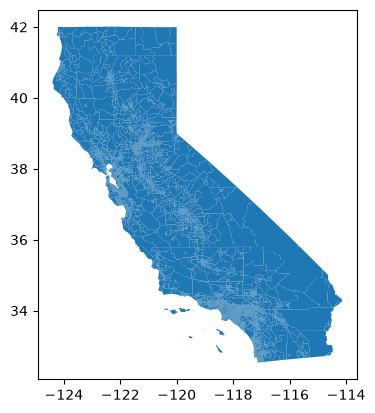

In [11]:
gdf.plot()

It worked! The x-axis is longitude in degrees from Greenwhich and y-axis is latitude.

Let's quickly discuss the other columns in the geodataframe. You can see state and county FIPS codes, 12-digit GEOID -- we'll use that to match with our VMT data -- unhelpful names, and ALAND and AWATER: these are areas in units of square meters. Let's confirm that.

In [12]:
gdf['ALAND'].sum() / 1e6 # convert from square meters to square kilometers

np.float64(403660.088482)

404,000 km$^2$ approximately matches Wikipedia's California [entry](https://en.wikipedia.org/wiki/California).

Finally, let's extract only San Francisco County. A quick web-search finds SF's county code is "075". So we'll keep where `COUNTYFP` == '075'.

In [13]:
sf_shape = gdf[gdf['COUNTYFP'] == '075']
# This is a basic dataframe filter. Inside the brackets we are creating a logical series and then selecting the
# rows where the logical is True.
# Compare lengths:
len(sf_shape)

580

In [14]:
len(gdf)

23196

<Axes: >

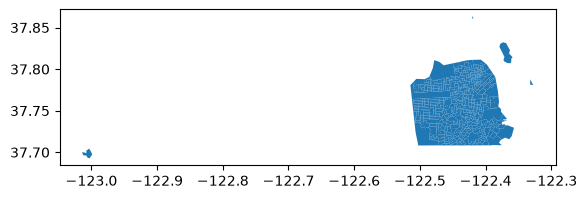

In [15]:
sf_shape.plot()

That's SF! Plus Treasure Island and the Farallones.

In [16]:
sf_shape['ALAND'].sum() / 1e6 / 1.61**2 # convert from square meters to square miles, since we know SF is about 49 sq mi

np.float64(46.86460514640638)

### Merge
Now we want to merge. This is a whole topic worth reading up on, also covered in the [Python for Excel Users](https://nostarch.com/python-excel) book, the pandas [documentation](https://pandas.pydata.org/docs/user_guide/merging.html), and by [Datanovia](https://www.datanovia.com/learn/programming/python-data-wrangling/combine-data-merge-join).

The key is to carefully choose an inner, outer, left, or right merge method: this will keep intersecting (matched) indices, all indices including unmatches, or the original left or right dataframe's indices. (Left/right is defined by the first of the two appearing in your merge call.) Make sure that the lengths of the original and merged datatables match or differ as expected.

In this case we want to keep only the SF rows from the VMT data, so we'll do an inner merge and confirm we didn't lose any. To keep the geodataframe attributes, we need to use the sf_shape as the left variable.

You also have to tell it which column to use as an index which you want to "key" on to merge -- i.e. how to match rows.

In [17]:
merged = sf_shape.merge(vmt, left_on='GEOID', right_index=True, how='inner')
# This means merge keying on the GEOID column of the left variable, the index of the right variable, using merge
# method inner.
# First check the length.
len(merged)

580

That's good: we didn't lose any of our block groups in the SF dataframe when merging into the larger vmt dataframe.

Let's take a look at the form.

In [18]:
merged.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,VMTpc
7,06,075,010800,1,1500000US060750108001,060750108001,1,BG,92109,0,"POLYGON ((-122.41722 37.79847, -122.41228 37.7...",3.991582
16,06,075,061100,2,1500000US060750611002,060750611002,2,BG,54921,0,"POLYGON ((-122.40825 37.79582, -122.40514 37.7...",3.991582
18,06,075,012800,4,1500000US060750128004,060750128004,4,BG,73689,0,"POLYGON ((-122.44747 37.79939, -122.44118 37.8...",3.991582
29,06,075,061400,3,1500000US060750614003,060750614003,3,BG,137098,0,"POLYGON ((-122.40369 37.75701, -122.39797 37.7...",3.991582
57,06,075,015600,2,1500000US060750156002,060750156002,2,BG,83091,0,"POLYGON ((-122.4585 37.77619, -122.45686 37.77...",3.991582


Let's set the index to GEOID again and just keep the vmt and geometry columns.

In [19]:
sf_vmt = merged.set_index('GEOID')[['VMTpc', 'geometry']]
sf_vmt.head()

,VMTpc,geometry
GEOID,,
060750108001,3.991582,"POLYGON ((-122.41722 37.79847, -122.41228 37.7..."
060750611002,3.991582,"POLYGON ((-122.40825 37.79582, -122.40514 37.7..."
060750128004,3.991582,"POLYGON ((-122.44747 37.79939, -122.44118 37.8..."
060750614003,3.991582,"POLYGON ((-122.40369 37.75701, -122.39797 37.7..."
060750156002,3.991582,"POLYGON ((-122.4585 37.77619, -122.45686 37.77..."


### Map

Now we're ready for an interactive map. We'll use `explore` instead of `plot` this time.

In [20]:
sf_vmt.explore(column='VMTpc', tiles='CartoDB positron', cmap='jet',
              vmin=4, vmax=15)
# Plot the column VMTpc, using the background defined by 'CartoDB positron', and the colormap 'jet'.

Notes on the function arguments selected:
- The "CartoDB positron" uses a cleaner background than the default Open Street Map background. It paints in an annoying API KEY REQUIRED but we're not going for publication-ready here so we'll ignore that.
- "jet" is a higher contrast colormap than the default which shows high as red and low as blue. You can check out the full set of built-in [Matplotlib colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html).
- vmin and vmax cap the colorbar. I chose these by trial and error as it seems like within the city
proper it tops out at 15 VMT/person/day and the whole upper right quadrant of the city bottoms out
at just under 4 VMT/person/day.


The pattern is understandable: the downtown defines the lowest VMT in the state, and the more car-oriented neighborhoods to the west and south have higher VMT, but all still lower than the statewide
average of 18 VMT/person/day.

For better or worse, the spatial pattern is simpler with less variance than that shown
in [Replica's](https://replicahq.com/) proprietary VMT estimates which were illustrated in
Subin [2024](https://ternercenter.berkeley.edu/research-and-policy/role-of-new-housing-in-reducing-climate-pollution/); though there SF is nearly all at the very bottom of the colormap so you can only see the variation using the tooltip (i.e. mousing over).

## Step 3: Merge with ACS population and housing data.

Here we could do this the fancy way with the census API following Quinn's demo, but we'll do it the old-fashioned
way by downloading a csv from the [census data portal](https://data.census.gov/advanced) so you can see exactly what is going on, and to avoid managing a local API key that is not checked into GitHub.

    🤓 A more advanced source for census data used by researchers is [IPUMS NHGIS](https://www.nhgis.org/) hosted by the University of Minnesota. You have to create an account but it makes it easier to download across many years and geographies.

To get close to 2017, we'll use the American Community Survey (ACS) 5-year estimates spanning 2015-2019; 5-year estimates provide sufficient sampling for census to report block-group level data. (This will also ensure that we don't have to remap census block group boundaries across a major census year.)

### Population
We fill out the filters on the census website for California census block groups, 5-yr ACS ending in 2019, to narrow down to variable "B01003" for "TOTAL POPULATION".
![](CensusDataScreenshot.png)

We click through to download the table as a csv. It comes as a zip with helpful metadata, though this particular variable is self-explanatory. Remember that variables
ending in 'E' are generally the estimates we want to use, while those ending in 'M' are the statistical margin of error.

In [21]:
ca_pop_data_file = inputdir / 'ACSDT5Y2019.B01003-Data.csv'
ca_pop_data = pd.read_csv(ca_pop_data_file)
ca_pop_data.head()

,GEO_ID,NAME,B01003_001E,B01003_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Total,Margin of Error!!Total,NaN
1,1500000US060014001001,"Block Group 1, Census Tract 4001, Alameda Coun...",3120,208,NaN
2,1500000US060014002001,"Block Group 1, Census Tract 4002, Alameda Coun...",990,138,NaN
3,1500000US060014002002,"Block Group 2, Census Tract 4002, Alameda Coun...",1017,123,NaN
4,1500000US060014003001,"Block Group 1, Census Tract 4003, Alameda Coun...",1134,238,NaN


We'll have to do some cleaning. First, the second row appears to be metadata. Let's try reloading using the `skiprows`
argument to `read_csv`. Note that we want to skip row #1 (0-indexed), _not_ 1 row, so we have to put the 1 in brackets
to tell it we are providing a list of row numbers.

(We don't want to just drop the row, because having it there could change how pandas infers the data type of the columns.)

In [22]:
ca_pop_data = pd.read_csv(ca_pop_data_file, skiprows=[1])
ca_pop_data.head()

,GEO_ID,NAME,B01003_001E,B01003_001M,Unnamed: 4
0,1500000US060014001001,"Block Group 1, Census Tract 4001, Alameda Coun...",3120,208,NaN
1,1500000US060014002001,"Block Group 1, Census Tract 4002, Alameda Coun...",990,138,NaN
2,1500000US060014002002,"Block Group 2, Census Tract 4002, Alameda Coun...",1017,123,NaN
3,1500000US060014003001,"Block Group 1, Census Tract 4003, Alameda Coun...",1134,238,NaN
4,1500000US060014003002,"Block Group 2, Census Tract 4003, Alameda Coun...",1237,263,NaN


That's better. Now we need to trim the "1500000US" from each GEO_ID. Let's make a new column named
GEOID to match our other variables.

In [23]:
len("1500000US")

9

In [24]:
ca_pop_data['GEOID'] = ca_pop_data['GEO_ID'].map(lambda x: x[9:]) # for each element, which is a string,
# slice off the first 9 characters.
ca_pop_data.head()

,GEO_ID,NAME,B01003_001E,B01003_001M,Unnamed: 4,GEOID
0,1500000US060014001001,"Block Group 1, Census Tract 4001, Alameda Coun...",3120,208,NaN,060014001001
1,1500000US060014002001,"Block Group 1, Census Tract 4002, Alameda Coun...",990,138,NaN,060014002001
2,1500000US060014002002,"Block Group 2, Census Tract 4002, Alameda Coun...",1017,123,NaN,060014002002
3,1500000US060014003001,"Block Group 1, Census Tract 4003, Alameda Coun...",1134,238,NaN,060014003001
4,1500000US060014003002,"Block Group 2, Census Tract 4003, Alameda Coun...",1237,263,NaN,060014003002


That looks good. Just to be sure let's find the min and max length of the GEOID elements.

In [25]:
ca_pop_data['GEOID'].map(len).max()
# Apply the [built-in python] "len" function to each element, then take the max of the resulting sseries.

np.int64(12)

In [26]:
ca_pop_data['GEOID'].map(len).min()

np.int64(12)

Great. Now let's clean it up by setting GEOID to the index, renaming the column of interest, and dropping the others.

In [27]:
pop = ca_pop_data.set_index('GEOID')[['B01003_001E']].rename({'B01003_001E': 'Population'}, axis=1)
pop.head()

,Population
GEOID,
060014001001,3120
060014002001,990
060014002002,1017
060014003001,1134
060014003002,1237


In [28]:
pop.sum()

Population    39283497
dtype: int64

The sum is as expected.

### Housing
Let's follow the same steps for variable "B25001", "HOUSING UNITS".

We'll practice combining the steps into a function, assuming all the tables have the same format.

In [29]:
def read_census_table(table_name, filename, variable_name,
                      skiprows=[1], inputdir=inputdir, geo_in_name='GEO_ID', geo_out_name='GEOID', trim_length=9,
                      column_suffix='_001E'):
    # Function header defines the function name and its arguments.
    # Ideally, you would document the expected data type, units, or other conventions for each of these arguments.
    # Notice the first set of arguments are left open while the others have defaults set. This way we can
    # have it work as above but if we had to customize one of these options later they wouldn't be hard-coded.

    # Read data
    data = pd.read_csv(inputdir / filename, skiprows=skiprows)

    # Trim leading FIPS code strings.
    data[geo_out_name] = data[geo_in_name].map(lambda x: x[trim_length:])

    # Set index, rename column to something more readable, and drop other columns.
    column_name = table_name + column_suffix # Using '+' for a string concatenates.
    data_out = data.set_index(geo_out_name)[[column_name]].rename({column_name: variable_name}, axis=1)
    
    return data_out

We've combined all the steps, defining some variables typically changed and others with default values.
If we wanted, we could move this function outside of this notebook altogether into its own .py module and
make it available for reuse.

First, let's test it to make sure it reproduces the population for the above case!

In [30]:
read_census_table('B01003', 'ACSDT5Y2019.B01003-Data.csv', 'Population').sum()

Population    39283497
dtype: int64

Good. Now call for the new variable, and instead of just printing the sum,
save the result to a new local variable.

In [31]:
housing_units = read_census_table('B25001', 'ACSDT5Y2019.B25001-Data.csv', 'Housing Units')
housing_units.head()

,Housing Units
GEOID,
060014001001,1354
060014002001,435
060014002002,425
060014003001,449
060014003002,758


In [32]:
housing_units.sum()

Housing Units    14175976
dtype: int64

In [33]:
pop.sum().values / housing_units.sum().values

array([2.77113174])

So there is an average of 2.77 people per housing unit. This is of the expected magnitude.

    🤓 People per housing unit will be slightly lower than people per household, as some housing units are second homes or vacant. ACS also has an occupied housing units variable and a households variable if we wanted to compare.

### Merge
First let's go back to the overall state VMT data. We'd like to see how the stats change
when we weight the average by population.

In [34]:
len(pop)

23212

In [35]:
len(housing_units)

23212

In [36]:
len(vmt)

23190

In [37]:
vmt_merged = vmt.merge(pop, left_index=True, right_index=True, how='inner')
vmt_merged = vmt_merged.merge(housing_units, left_index=True, right_index=True, how='inner')
vmt_merged.head()

,VMTpc,Population,Housing Units
GEOID,,,
060259400003,24.496582,382,485
060250108002,24.612582,809,332
060250108001,24.641582,319,158
060250111003,24.642582,2010,669
060730100132,15.780582,3148,879


In [38]:
len(vmt_merged)

23190

Looks good and we didn't lose any block groups so the keys were aligned (e.g. same census decade) and the merge was successful.

## Step 4: Descriptive stats

### Weighted averages
Let's calculate the population-weighted average statewide VMT. If we did this right and it matches
the description of the source data, it should be identical to the average state VMT we assumed above.

**Pay attention to this weighted average syntax, we'll be doing this a lot!**

$$\bar{x} = \frac{\sum_i(x_i*w_i)}{\sum_i(w_i)}$$

$\bar{x}$ is the weighted average of $x$ (e.g. the VMT);
$i$ is the index (e.g. the block groups);
and $w$ is the weight (e.g. the population).

In [39]:
statewide_mean_vmt_calc = (vmt_merged['VMTpc'] * vmt_merged['Population']).sum() / vmt_merged['Population'].sum()
statewide_mean_vmt_calc

np.float64(18.135571996504336)

In [40]:
statewide_mean_vmt_calc - VMT_state

np.float64(0.008989718023322268)

The discrepancy is smaller than 0.01 VMT, reasonably due to rounding error or a few dropped block groups.

We could do a weighted average by the housing distribution as well; it might be a bit lower since
urban housing units tend to have modestly smaller household sizes.

In [41]:
(vmt_merged['VMTpc'] * vmt_merged['Housing Units']).sum() / vmt_merged['Housing Units'].sum()

np.float64(18.10789428683938)

Very slightly lower.

### Histograms
We can also look at the whole distribution, population-weighted. We can use the built-in
matplotlib `hist` (histogram) function which takes a weight argument.

Text(0, 0.5, 'Million People')

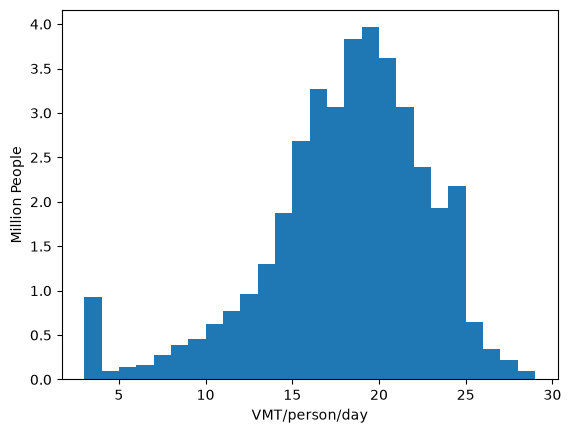

In [42]:
plt.hist(vmt_merged['VMTpc'], weights=vmt_merged['Population'] / 1e6, bins=np.arange(3, 30))
# Set bins to be 1 VMT from 3 to 30, use millions of people for plotting convenience.
plt.xlabel('VMT/person/day')
plt.ylabel('Million People')

This is OK but it is still unrealistically left-skewed, which is disappointing. It will have to do
until we get access to Replica!

For comparison, we can show the unweighted. Now the y-axis will be number of block groups.

Text(0.5, 0, 'VMT/person/day')

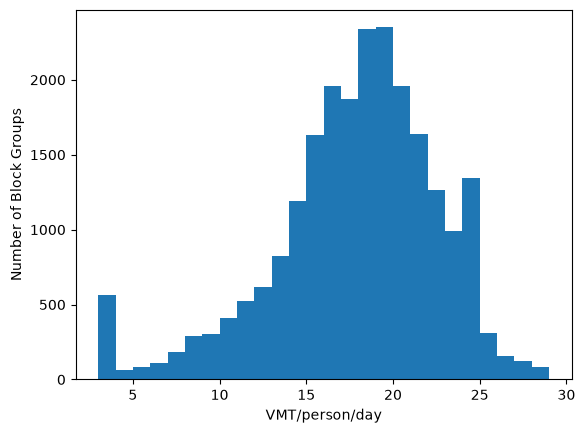

In [43]:
plt.hist(vmt_merged['VMTpc'], bins=np.arange(3, 30))
plt.ylabel('Number of Block Groups')
plt.xlabel('VMT/person/day')

### Scatterplot
We can merge with the statewide gdf and get a crude population density metric (which will include parks and non-residential land, etc.) to illustrate a scatterplot and correlation.

In [44]:
vmt_merged = vmt_merged.merge(gdf[['GEOID', 'ALAND']], left_index=True, right_on='GEOID', how='inner')
vmt_merged = vmt_merged.set_index('GEOID')
vmt_merged.head()

,VMTpc,Population,Housing Units,ALAND
GEOID,,,,
060259400003,24.496582,382,485,12261531
060250108002,24.612582,809,332,59331725
060250108001,24.641582,319,158,230656792
060250111003,24.642582,2010,669,1267850
060730100132,15.780582,3148,879,404606


In [45]:
len(vmt_merged)

23190

In [46]:
vmt_merged['Population Density'] = vmt_merged['Population'] / vmt_merged['ALAND'] * 1e6 * 1.61**2
# people/m^2 * m^2/km^2 * km^2/mi^2 = people/mi^2.
vmt_merged.describe()

,VMTpc,Population,Housing Units,ALAND,Population Density
count,23190.000000,23190.000000,23190.000000,2.319000e+04,23190.000000
mean,17.870123,1693.984347,611.296938,1.740664e+07,9417.824593
std,4.770563,1116.008225,376.984896,2.047075e+08,10211.857747
min,3.991582,0.000000,0.000000,1.540600e+04,0.000000
25%,15.421832,1031.000000,380.000000,2.989952e+05,3243.531301
50%,18.429582,1475.000000,530.000000,5.462205e+05,7014.690663
75%,21.062582,2076.000000,747.000000,1.296322e+06,12071.608896
max,28.802582,38754.000000,7624.000000,1.599336e+10,188611.196936


VMT tends to relate to log(population density).

Text(0.5, 0, 'Log$_{10}$ Population Density (people per sq mi)')

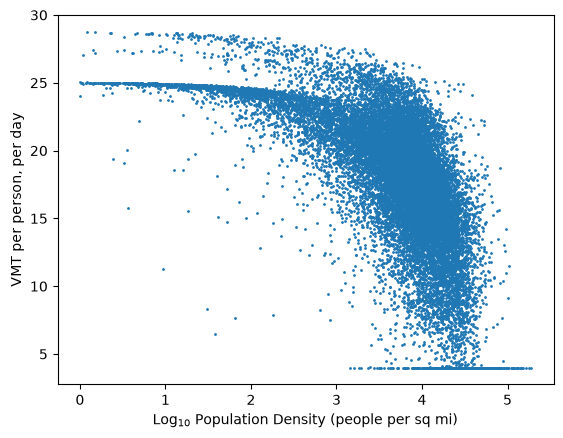

In [47]:
# Scatterplot
# First filter to rows with > 0 pop density. We'll use > 1 to avoid small floating point issues.
vmt_subset = vmt_merged[vmt_merged['Population Density'] > 1]

plt.scatter(np.log10(vmt_subset['Population Density']), vmt_subset['VMTpc'], s=1)
# scatter(x, y); we set optional argument s=1 to keep the markers small.
plt.ylabel('VMT per person, per day')
plt.xlabel('Log$_{10}$ Population Density (people per sq mi)')

There are definitely several artifacts visible here indicating model truncation at both ends. Sigh.
But at least the inverse relationship is visible. We can see this directly using the built-in correlation
function in `numpy` (much more sophisticated stats libraries are also available for python).

In [48]:
np.corrcoef(np.log10(vmt_subset['Population Density']), vmt_subset['VMTpc'])

array([[ 1.        , -0.63766904],
       [-0.63766904,  1.        ]])

So they are inversely correlated with a correlation coefficient of -0.64.

### SF pop-weighted average and distribution

Finally, let's subset merge the population and housing data into the `sf_vmt` geodataframe. 

In [49]:
len(sf_vmt)

580

In [50]:
sf_vmt = sf_vmt.merge(pop, left_index=True, right_index=True, how='inner')
sf_vmt = sf_vmt.merge(housing_units,left_index=True, right_index=True, how='inner') 
len(sf_vmt)

580

In [51]:
sf_vmt.head()

,VMTpc,geometry,Population,Housing Units
GEOID,,,,
060750108001,3.991582,"POLYGON ((-122.41722 37.79847, -122.41228 37.7...",1680,798
060750611002,3.991582,"POLYGON ((-122.40825 37.79582, -122.40514 37.7...",2791,1294
060750128004,3.991582,"POLYGON ((-122.44747 37.79939, -122.44118 37.8...",506,586
060750614003,3.991582,"POLYGON ((-122.40369 37.75701, -122.39797 37.7...",1234,628
060750156002,3.991582,"POLYGON ((-122.4585 37.77619, -122.45686 37.77...",1848,697


In [52]:
sf_popmean_vmt = (sf_vmt['VMTpc'] * sf_vmt['Population']).sum() / sf_vmt['Population'].sum()
sf_popmean_vmt

np.float64(5.868372933150193)

In [53]:
sf_popmean_vmt - statewide_mean_vmt_calc

np.float64(-12.267199063354143)

**So the average SF resident drives 12.3 mi less each day than the average CA resident.**

Let's look at the distribution. We'll print deciles using the built-in [quantile](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html) function, which
takes in weights as an optional argument. However, (somewhat annoyingly) using weights requires setting 
a second optional argument to use a non-default interpolation method. (If you forget it throws an error.)

Note: you need numpy version 2 or greater to evaluate this function. In most cases this will load from the engy680
environment we set up, but ask for a workaround if this causes trouble.

In [54]:
deciles = np.arange(0, 1.1, 0.1)
sf_vmt_deciles = np.quantile(sf_vmt['VMTpc'], deciles, weights=sf_vmt['Population'],
                            method='inverted_cdf')

# To make it easier to look at, let's make a dictionary using "Dictionary Comprehension" (e.g. https://www.geeksforgeeks.org/python/python-dictionary-comprehension/).
sf_vmt_deciles = {round(deciles[x], 1): round(sf_vmt_deciles[x], 1) for x in range(len(deciles))}
sf_vmt_deciles

{np.float64(0.0): np.float64(4.0),
 np.float64(0.1): np.float64(4.0),
 np.float64(0.2): np.float64(4.0),
 np.float64(0.3): np.float64(4.0),
 np.float64(0.4): np.float64(4.0),
 np.float64(0.5): np.float64(4.0),
 np.float64(0.6): np.float64(6.0),
 np.float64(0.7): np.float64(7.3),
 np.float64(0.8): np.float64(8.2),
 np.float64(0.9): np.float64(9.1),
 np.float64(1.0): np.float64(17.8)}

The first entry is the min, the last is the max, and in between are deciles from 0.1 to 0.9.
aka percentiles from 10th percentile to 90th percentile.

OK well this is a pathological example: the median equals the 10th percentile! But for other cities or counties
we could have asked, how much lower is the VMT for 10th-percentile resident (or neighborhood -- if using unweighted quantiles) than the mean and median resident. And then we could estimate the VMT savings from siting housing there.

We could also look at how the VMT varies within the city relative to neighborhood demographics or housing
characteristics.